# Optimal flight booking simulation:

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
import sys
import os
import pandas as pd
!pip install -q pyspark
from pyspark.sql import SparkSession
from pyspark import SparkContext, SparkConf
from pyspark.sql.functions import avg, sum, max
from pyspark.sql.functions import dayofweek, date_format
import pyspark.sql.functions as func
from pyspark.sql.functions import col
from pyspark.sql.window import Window

GOOGLE_DRIVE_PATH_AFTER_MYDRIVE = '/content/drive/My Drive/CIS 5570/Project 5570'
assert GOOGLE_DRIVE_PATH_AFTER_MYDRIVE is not None
GOOGLE_DRIVE_PATH = os.path.join('drive', 'My Drive', GOOGLE_DRIVE_PATH_AFTER_MYDRIVE)
sys.path.append(GOOGLE_DRIVE_PATH)

conf = SparkConf().setAppName('SparkFlightRecommender')
sc = SparkContext.getOrCreate(conf = conf)

spark = SparkSession.builder\
        .master("local")\
        .appName("SparkByExamples.com")\
        .getOrCreate()

df = spark.read.options(header='True', inferSchema='True', delimiter=',') \
  .csv("/content/drive/My Drive/CIS 5570/Project 5570/Itineraries.csv")

#Showing selected 10 columns
df_selected_column = df.select("flightDate", "startingAirport","destinationAirport", "isBasicEconomy", "isRefundable", "baseFare", "totalFare", "seatsRemaining", "segmentsAirlineCode", "searchDate")
sampled_df = df_selected_column.sample(withReplacement=False, fraction=200/1_000_000, seed=42).limit(200)
sampled_df.show()


Mounted at /content/drive
+----------+---------------+------------------+--------------+------------+--------+---------+--------------+-------------------+----------+
|flightDate|startingAirport|destinationAirport|isBasicEconomy|isRefundable|baseFare|totalFare|seatsRemaining|segmentsAirlineCode|searchDate|
+----------+---------------+------------------+--------------+------------+--------+---------+--------------+-------------------+----------+
|2022-06-02|            MIA|               LGA|         false|       false|    26.0|   133.58|             0|             NK||NK|2022-05-12|
|2022-07-23|            MIA|               DEN|         false|       false|  530.23|    593.6|             7|             DL||DL|2022-06-22|
|2022-06-25|            LGA|               ORD|         false|       false|  226.98|    258.6|            10|                 AA|2022-05-13|
|2022-05-29|            DFW|               SFO|         false|       false|  125.01|   148.99|             4|                 F9

Average Price Analysis:

In [ ]:
df_markup = sampled_df.withColumn("markup", col("totalFare") - col("baseFare"))
df_markup_percentage = df_markup.withColumn("markupPercent", (col("markup") / col("baseFare")) * 100)

df_avg_prices = df_markup_percentage.agg(
    avg("baseFare").alias("avgBaseFare"),
    avg("totalFare").alias("avgTotalFare"),
    avg("markup").alias("avgMarkup"),
    avg("markupPercent").alias("avgMarkupPercent")
)
df_avg_prices.show()

+------------------+------------------+-----------------+------------------+
|       avgBaseFare|      avgTotalFare|        avgMarkup|  avgMarkupPercent|
+------------------+------------------+-----------------+------------------+
|330.52534999999983|381.27064999999965|50.74530000000001|28.400246637289744|
+------------------+------------------+-----------------+------------------+



Grouped and sorted data:

In [ ]:
#Adding grouped average
df_grouped_avg = sampled_df.groupBy("flightDate", "startingAirport","totalFare","baseFare").agg(avg("baseFare").alias("AvgAgg_BaseFare"))
df_grouped_data = sampled_df.groupBy("flightDate", "startingAirport","destinationAirport", "searchDate","totalFare","baseFare").agg(avg("baseFare").alias("AvgAgg_BaseFare"))

#df_sorted_dsc = df_grouped_data.orderBy(col("Avg_BaseFare").desc())
df_sorted_asc = df_grouped_data.orderBy(col("AvgAgg_BaseFare"))
df_sorted_asc.show()

+----------+---------------+------------------+----------+---------+--------+---------------+
|flightDate|startingAirport|destinationAirport|searchDate|totalFare|baseFare|AvgAgg_BaseFare|
+----------+---------------+------------------+----------+---------+--------+---------------+
|2022-05-24|            LAX|               DEN|2022-04-22|    42.79|     5.2|            5.2|
|2022-06-02|            MIA|               LGA|2022-05-12|   133.58|    26.0|           26.0|
|2022-06-21|            PHL|               CLT|2022-05-27|   138.96|   31.38|          31.38|
|2022-06-14|            BOS|               EWR|2022-05-22|     54.6|   37.21|          37.21|
|2022-06-19|            ORD|               LGA|2022-05-26|   160.58|    53.0|           53.0|
|2022-08-11|            LAX|               OAK|2022-06-22|   125.58|    56.0|           56.0|
|2022-05-11|            CLT|               BOS|2022-05-09|     86.1|   59.53|          59.53|
|2022-07-22|            DEN|               DFW|2022-06-15|  

Fare change analysis

In [ ]:
# Adding new column- Day_name to show weekends and weekdays
df_with_dayname = df_sorted_asc.withColumn("day_name", date_format("flightDate", "EEEE"))

#Adding fare-change (with magical number: Data_point):
df_with_fareChange = df_with_dayname.withColumn("fareChange", df_sorted_asc["totalFare"] - df_sorted_asc["AvgAgg_BaseFare"])
df_with_fareChange.show()

+----------+---------------+------------------+----------+---------+--------+---------------+---------+------------------+
|flightDate|startingAirport|destinationAirport|searchDate|totalFare|baseFare|AvgAgg_BaseFare| day_name|        fareChange|
+----------+---------------+------------------+----------+---------+--------+---------------+---------+------------------+
|2022-05-24|            LAX|               DEN|2022-04-22|    42.79|     5.2|            5.2|  Tuesday|37.589999999999996|
|2022-06-02|            MIA|               LGA|2022-05-12|   133.58|    26.0|           26.0| Thursday|107.58000000000001|
|2022-06-21|            PHL|               CLT|2022-05-27|   138.96|   31.38|          31.38|  Tuesday|107.58000000000001|
|2022-06-14|            BOS|               EWR|2022-05-22|     54.6|   37.21|          37.21|  Tuesday|             17.39|
|2022-06-19|            ORD|               LGA|2022-05-26|   160.58|    53.0|           53.0|   Sunday|107.58000000000001|
|2022-08-11|    

Optimal window booking

+----------+---------------+------------------+----------+---------+--------+---------------+---------+---------------------+-------------------------+
|flightDate|startingAirport|destinationAirport|searchDate|totalFare|baseFare|AvgAgg_BaseFare| day_name|days_before_departure|Optimal_window_forBooking|
+----------+---------------+------------------+----------+---------+--------+---------------+---------+---------------------+-------------------------+
|2022-08-01|            ATL|               DTW|2022-06-18|    298.6|  264.19|         264.19|   Monday|    INTERVAL '44' DAY|                       44|
|2022-06-24|            ATL|               ORD|2022-06-03|    378.6|   338.6|          338.6|   Friday|    INTERVAL '21' DAY|                       21|
|2022-06-28|            ATL|               DTW|2022-05-03|   168.61|  143.26|         143.26|  Tuesday|    INTERVAL '56' DAY|                       56|
|2022-07-24|            ATL|               BOS|2022-06-12|    571.6|  509.77|         50

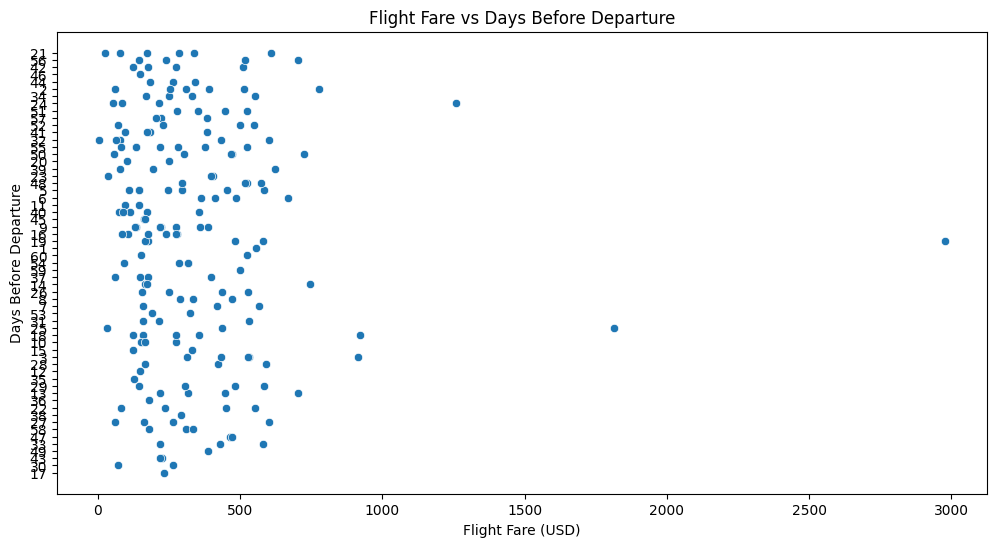

In [ ]:
from pyspark.sql.functions import rand, round
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.model_selection import train_test_split
from pyspark.sql.functions import regexp_extract

df_departure_days = df_with_dayname.withColumn("days_before_departure", col("flightDate") - col("searchDate"))
df_days = df_departure_days.withColumn("Optimal_window_forBooking", regexp_extract(df_departure_days["days_before_departure"], r"\d+", 0))

#df_days = df.withColumn("days_intervalDepart", df["days_interval"].cast("int"))
#all_prices = df_departure_days.withColumn("price", col("AvgAgg_BaseFare") + col("price_variation"))
#df_rand = df_departure_days.withColumn("random_dayInterval", round(rand() * (90 - 10) + 10, 10))
#df_with_random_int = df_rand.select("days_before_departure", "random_dayInterval")

#Adding days_before_departure:
df_sorted_asc = df_days.orderBy("startingAirport")
df_sorted_asc.toPandas().to_csv('output.csv', index=False)
df_sorted_asc.show()

pandas_df = df_sorted_asc.toPandas()
plt.figure(figsize=(12, 6))
sns.scatterplot(x='AvgAgg_BaseFare', y='Optimal_window_forBooking', data=pandas_df)
plt.title('Flight Fare vs Days Before Departure')
plt.xlabel('Flight Fare (USD)')
plt.ylabel('Days Before Departure')
plt.grid(False)
plt.show()


Regression analysis for optimal window for booking

[[ 151.54]
 [ 528.37]
 [ 352.55]
 [ 413.03]
 [   5.2 ]
 [ 473.  ]
 [ 161.86]
 [  78.14]
 [ 296.75]
 [ 396.28]
 [ 466.04]
 [ 152.56]
 [ 310.7 ]
 [ 264.19]
 [ 445.59]
 [ 437.21]
 [ 385.12]
 [ 293.03]
 [  53.  ]
 [ 527.45]
 [  87.44]
 [ 548.84]
 [  59.53]
 [  78.14]
 [ 556.28]
 [ 204.08]
 [  59.89]
 [ 552.56]
 [ 171.17]
 [ 290.23]
 [ 240.  ]
 [ 219.53]
 [ 177.67]
 [ 500.46]
 [ 333.03]
 [ 311.63]
 [  96.74]
 [ 530.23]
 [ 283.72]
 [ 316.28]
 [ 509.77]
 [ 217.67]
 [ 251.16]
 [ 602.79]
 [ 512.56]
 [ 175.82]
 [ 430.7 ]
 [ 522.79]
 [ 468.84]
 [ 922.78]
 [ 524.65]
 [ 252.09]
 [ 390.7 ]
 [ 278.14]
 [ 184.  ]
 [ 915.35]
 [ 180.47]
 [ 249.31]
 [ 432.56]
 [  78.14]
 [ 264.19]
 [ 386.05]
 [  64.19]
 [ 217.67]
 [ 354.42]
 [ 273.49]
 [ 227.91]
 [ 213.72]
 [ 445.58]
 [ 162.79]
 [  85.58]
 [ 338.6 ]
 [ 273.49]
 [ 219.  ]
 [ 485.58]
 [ 386.05]
 [ 273.49]
 [ 164.65]
 [  82.79]
 [ 171.17]
 [ 166.51]
 [ 280.35]
 [ 581.4 ]
 [ 567.45]
 [ 102.33]
 [ 245.58]
 [ 143.26]
 [ 194.42]
 [ 524.65]
 [ 222.68]
 [ 157.21]

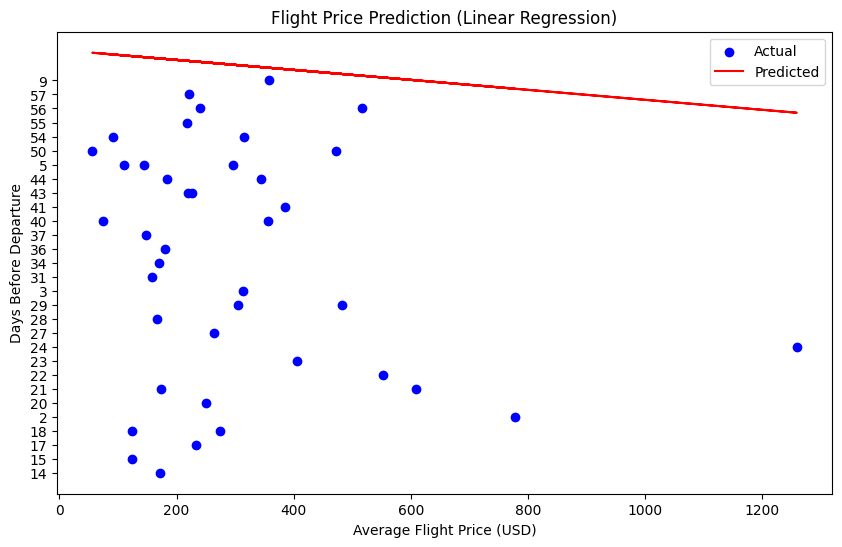

In [ ]:
X = pandas_df['AvgAgg_BaseFare'].values.reshape(-1,1)  # Feature (price)
y = pandas_df['Optimal_window_forBooking'].values  # Target (days before departure)

# Train a Linear Regression Model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train)
print(y_train)
print(X_test)
print(y_test)

regressor = LinearRegression()
regressor.fit(X_train, y_train)

# Predict prices
y_pred = regressor.predict(X_test)

# Combine and sort
df_temp = pd.DataFrame({'X_test': X_test.flatten(), 'y_test': y_test.flatten(), 'y_pred': y_pred.flatten()})
df_temp_sorted = df_temp.sort_values(by='y_test')

# Plotting
plt.figure(figsize=(10, 6))
plt.scatter(df_temp_sorted['X_test'], df_temp_sorted['y_test'], color='blue', label='Actual')
plt.plot(df_temp_sorted['X_test'], df_temp_sorted['y_pred'], color='red', label='Predicted')

#plt.scatter(X_test, y_test, color='blue', label='Prices')
#plt.plot(X_test, y_pred, color='red', label='Regression Line')
plt.title('Flight Price Prediction (Linear Regression)')
plt.xlabel('Average Flight Price (USD)')
plt.ylabel('Days Before Departure')
plt.legend()
plt.grid(False)
plt.show()


Flight price forecasting for new entry

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


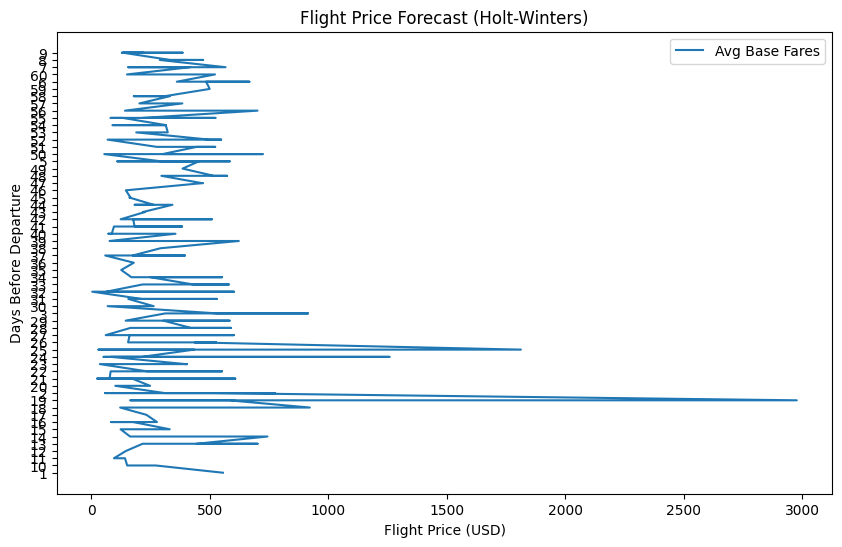

The optimal time to book a flight is around 43 days before departure.


In [ ]:
df_sorted = pandas_df.sort_values(by='Optimal_window_forBooking')

model = ExponentialSmoothing(df_sorted['AvgAgg_BaseFare'], trend='add', seasonal=None, damped_trend=False)
model_fit = model.fit()

# Forecast future prices (e.g., next 30 days)
forecast = model_fit.forecast(30)

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(df_sorted['AvgAgg_BaseFare'], df_sorted['Optimal_window_forBooking'], label='Avg Base Fares')
#plt.plot(range(df_sorted['Optimal_window_forBooking'].max(), df_sorted['Optimal_window_forBooking'].max() + 30), forecast, color='red', label='Forecasted Prices')
plt.title('Flight Price Forecast (Holt-Winters)')
plt.xlabel('Flight Price (USD)')
plt.ylabel('Days Before Departure')
plt.legend()
plt.grid(False)
plt.show()

# Step 5: Determine the Optimal Booking Time
# Find when prices are at a minimum and when they start rising
optimal_booking_window = df_sorted['Optimal_window_forBooking'].iloc[df_sorted['AvgAgg_BaseFare'].idxmin()]
print(f"The optimal time to book a flight is around {optimal_booking_window} days before departure.")


Prophet for time-series forecasting: SARIMA

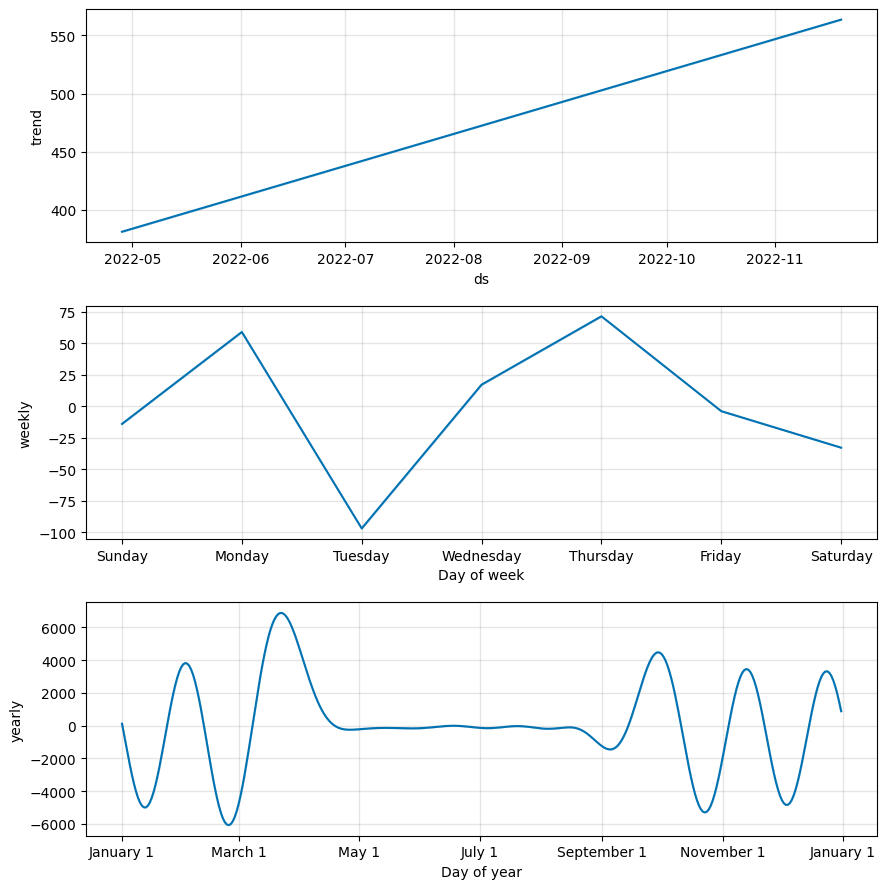

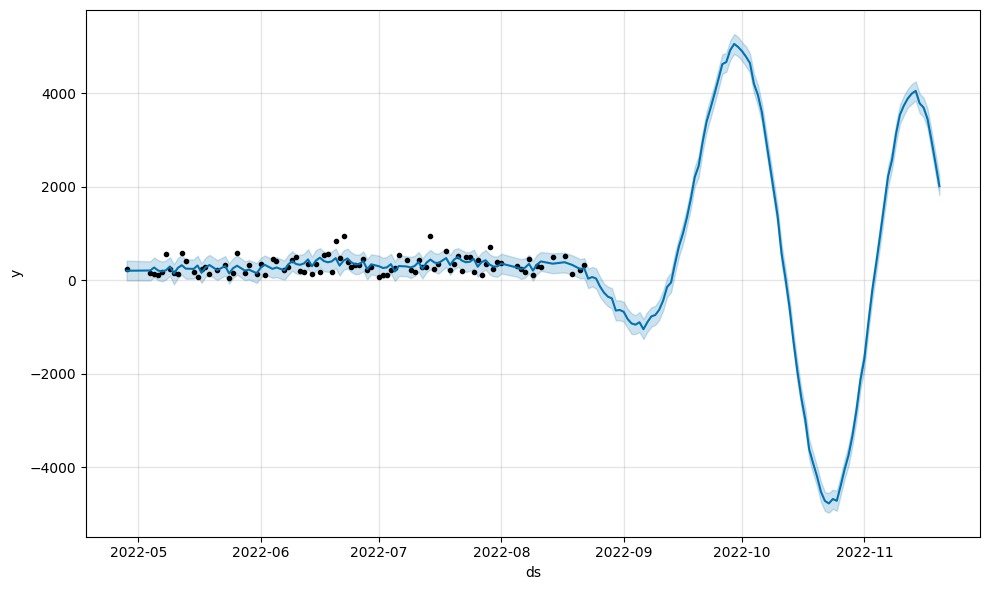

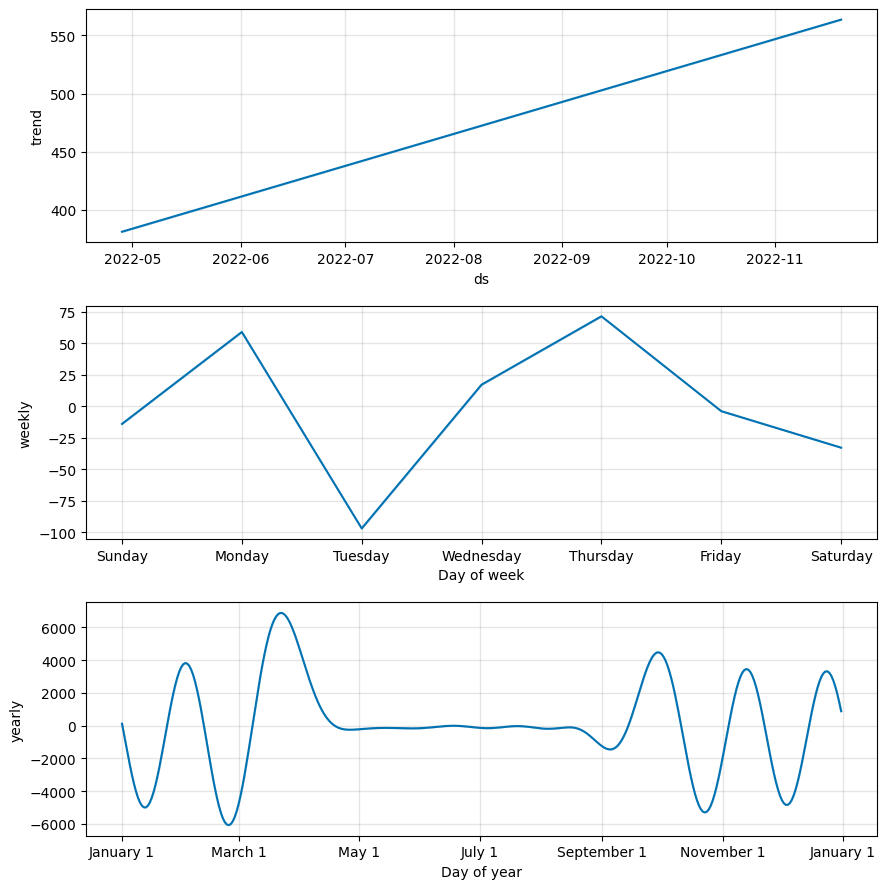

In [ ]:
from prophet import Prophet

# Prepare data: Prophet requires 'ds' (date) and 'y' (value)
prophet_df = pandas_df.groupby('flightDate')['AvgAgg_BaseFare'].mean().reset_index()
prophet_df.columns = ['ds', 'y']
prophet_df['ds'] = pd.to_datetime(prophet_df['ds'])

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.05  # controls flexibility
)
model.fit(prophet_df)

future = model.make_future_dataframe(periods=90)  # forecast 90 days ahead
forecast = model.predict(future)
model.plot(forecast)
model.plot_components(forecast)  # shows trend + weekly seasonality

Route-specific forecasting

In [ ]:
# Forecast per route, not globally
routes = pandas_df.groupby(['startingAirport', 'destinationAirport'])

for (origin, dest), group in routes:
    route_df = group.sort_values('flightDate')
    if len(route_df) < 10:
        continue
    # Train Prophet or ARIMA per route
    # Store model per route key: f"{origin}-{dest}"

Price elasticity by days_before_departure buckets

In [ ]:
# Bin days before departure into meaningful windows
bins = [0, 7, 14, 21, 30, 45, 60, 90, float('inf')]
labels = ['0-7', '8-14', '15-21', '22-30', '31-45', '46-60', '61-90', '90+']

pandas_df['booking_window_bucket'] = pd.cut(
    pandas_df['Optimal_window_forBooking'].astype(int),
    bins=bins, labels=labels
)

price_by_window = pandas_df.groupby('booking_window_bucket')['AvgAgg_BaseFare'].agg(['mean','std','min','max'])
print(price_by_window)
# This directly answers: "What's the cheapest booking window?"

                             mean         std    min      max
booking_window_bucket                                        
0-7                    409.033846  208.266833  59.53   915.35
8-14                   282.530000  169.684861  96.74   744.19
15-21                  367.585185  556.397076  26.00  2976.74
22-30                  372.443226  367.396171  31.38  1813.02
31-45                  248.555333  161.641409   5.20   623.26
46-60                  341.147660  169.606317  56.00   723.72
61-90                         NaN         NaN    NaN      NaN
90+                           NaN         NaN    NaN      NaN


/tmp/ipykernel_4950/2509994363.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_by_window = pandas_df.groupby('booking_window_bucket')['AvgAgg_BaseFare'].agg(['mean','std','min','max'])


# Airline & Booking Date Recommendations

Airline price comparison

In [ ]:
# Explode multi-segment airline codes (e.g., "AA||UA" → separate rows)
from pyspark.sql.functions import explode, split

df_airlines = sampled_df.withColumn(
    "airline", explode(split(col("segmentsAirlineCode"), r"\|\|"))
)

airline_stats = df_airlines.groupBy("airline").agg(
    avg("totalFare").alias("avg_fare"),
    avg("baseFare").alias("avg_base_fare"),
    (avg("totalFare") - avg("baseFare")).alias("avg_markup"),
    func.count("*").alias("flight_count")
).orderBy("avg_fare")

airline_stats.show()

+-------+------------------+------------------+------------------+------------+
|airline|          avg_fare|     avg_base_fare|        avg_markup|flight_count|
+-------+------------------+------------------+------------------+------------+
|     F9|           193.586|           163.148|30.438000000000017|           5|
|     NK|203.70416666666665|104.33166666666666| 99.37249999999999|          24|
|     9X|           203.805|160.83999999999997| 42.96500000000003|           4|
|     B6|            332.19| 293.4611764705882|38.728823529411784|          17|
|     AA| 370.9525806451609|  324.654946236559| 46.29763440860188|          93|
|     UA|461.53510638297837| 406.4425531914892| 55.09255319148917|          94|
|     DL| 464.0469791666663| 408.4372916666667| 55.60968749999961|          96|
|     AS| 527.9592857142858| 465.9664285714285|61.992857142857304|          14|
|     SY|             529.6|             473.0| 56.60000000000002|           2|
|     9K|            559.92|            

Best day-of-week to book AND to fly

In [ ]:
# Day to FLY (flightDate)
df_fly_day = sampled_df.withColumn("fly_day", date_format("flightDate", "EEEE"))
fly_day_prices = df_fly_day.groupBy("fly_day").agg(avg("totalFare").alias("avg_fare"))

# Day to SEARCH/BOOK (searchDate)
df_book_day = sampled_df.withColumn("book_day", date_format("searchDate", "EEEE"))
book_day_prices = df_book_day.groupBy("book_day").agg(avg("totalFare").alias("avg_fare"))

fly_day_prices.orderBy("avg_fare").show()
book_day_prices.orderBy("avg_fare").show()

+---------+------------------+
|  fly_day|          avg_fare|
+---------+------------------+
|  Tuesday| 272.5639285714287|
|   Sunday| 336.0245833333334|
| Saturday| 359.5267647058824|
|   Friday|404.27650000000006|
|Wednesday| 421.8752380952382|
| Thursday|428.37920000000014|
|   Monday| 437.7803703703706|
+---------+------------------+

+---------+------------------+
| book_day|          avg_fare|
+---------+------------------+
|   Monday| 316.6675000000001|
| Saturday| 350.3764516129033|
|Wednesday|          378.3275|
|   Sunday|380.99535714285724|
| Thursday|391.66527777777793|
|   Friday| 395.6941860465118|
|  Tuesday|469.06777777777785|
+---------+------------------+



Composite recommendation scorer

In [ ]:
def recommend_booking(origin, dest, budget, days_available, pandas_df):
    """Returns top 3 booking recommendations for a route."""
    route_df = pandas_df[
        (pandas_df['startingAirport'] == origin) &
        (pandas_df['destinationAirport'] == dest)
    ].copy()

    route_df['days'] = route_df['Optimal_window_forBooking'].astype(int)
    route_df['score'] = (
        (1 / route_df['totalFare']) * 0.5 +           # price weight
        (route_df['isRefundable'].astype(int)) * 0.3 + # refundability
        (~route_df['isBasicEconomy'].astype(bool)) * 0.2  # not basic economy
    )

    feasible = route_df[route_df['days'] <= days_available]
    return feasible.nlargest(3, 'score')[
        ['flightDate', 'airline', 'totalFare', 'isRefundable', 'score']
    ]

Switch from sampling to full dataset with PySpark aggregations

In [ ]:
# DON'T do this early: pandas_df = df.toPandas()
# DO aggregations in Spark first, then convert small result sets

route_summary = df.groupBy(
    "startingAirport", "destinationAirport",
    date_format("flightDate", "EEEE").alias("fly_day")
).agg(
    avg("totalFare").alias("avg_fare"),
    func.stddev("totalFare").alias("fare_stddev"),
    func.min("totalFare").alias("min_fare"),
    func.count("*").alias("num_flights")
)
# NOW convert — much smaller
pandas_summary = route_summary.toPandas()

Price alert threshold model

In [ ]:
# Flag a fare as a "deal" if it's below 1 std dev from route mean
window_spec = Window.partitionBy("startingAirport", "destinationAirport")

df_with_stats = df.withColumn("route_avg", avg("totalFare").over(window_spec)) \
                  .withColumn("route_std", func.stddev("totalFare").over(window_spec)) \
                  .withColumn("is_deal",
                      col("totalFare") < (col("route_avg") - col("route_std")))

df_with_stats.filter(col("is_deal")).show()

+--------------------+----------+----------+---------------+------------------+-------------+--------------+-----------+--------------+------------+---------+--------+---------+--------------+-------------------+---------------------------------+------------------------+-------------------------------+----------------------+--------------------------+----------------------------+-------------------+-------------------+----------------------------+-------------------------+----------------+-----------------+------------------+------------------+-------+
|               legId|searchDate|flightDate|startingAirport|destinationAirport|fareBasisCode|travelDuration|elapsedDays|isBasicEconomy|isRefundable|isNonStop|baseFare|totalFare|seatsRemaining|totalTravelDistance|segmentsDepartureTimeEpochSeconds|segmentsDepartureTimeRaw|segmentsArrivalTimeEpochSeconds|segmentsArrivalTimeRaw|segmentsArrivalAirportCode|segmentsDepartureAirportCode|segmentsAirlineName|segmentsAirlineCode|segmentsEquipmentDe

Feature Importance by Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import xgboost as xgb

# Get the columns to merge from sampled_df.toPandas()
sampled_pandas_df = sampled_df.toPandas()
cols_to_add = ['flightDate', 'startingAirport', 'destinationAirport', 'searchDate', 'totalFare', 'baseFare', 'isBasicEconomy', 'isRefundable', 'seatsRemaining']
# Ensure only relevant columns from sampled_df are taken to avoid re-introducing duplicate columns if they exist.
sampled_subset = sampled_pandas_df[cols_to_add]

# Perform a merge operation with the existing `pandas_df` to add the missing columns
# The existing `pandas_df` is derived from `df_sorted_asc`.
# Common merge keys are essential to correctly align data.
# The columns common to `pandas_df` (from df_sorted_asc) and `sampled_subset` are:
# 'flightDate', 'startingAirport', 'destinationAirport', 'searchDate', 'totalFare', 'baseFare'
final_pandas_df = pandas_df.merge(sampled_subset,
                                  on=['flightDate', 'startingAirport', 'destinationAirport', 'searchDate', 'totalFare', 'baseFare'],
                                  how='left')

# Convert Optimal_window_forBooking to integer and create day_of_week_num
final_pandas_df['days_before_departure_int'] = final_pandas_df['Optimal_window_forBooking'].astype(int)
final_pandas_df['day_of_week_num'] = pd.to_datetime(final_pandas_df['flightDate']).dt.dayofweek

# Update the `pandas_df` variable to this new, complete DataFrame
pandas_df = final_pandas_df

features = ['AvgAgg_BaseFare', 'seatsRemaining', 'isBasicEconomy',
            'isRefundable', 'day_of_week_num', 'days_before_departure_int']

X = pandas_df[features].fillna(0)
y = pandas_df['totalFare']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Feature importance tells you WHAT drives prices
feat_importance = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
print(feat_importance)

AvgAgg_BaseFare              0.836677
seatsRemaining               0.150271
day_of_week_num              0.007484
days_before_departure_int    0.005443
isBasicEconomy               0.000125
isRefundable                 0.000000
dtype: float64


Urgency tier

In [ ]:
# Flights with few seats tend to be cheaper OR about to spike — model this
df_urgency = sampled_df.withColumn(
    "urgency_tier",
    func.when(col("seatsRemaining") <= 3, "Critical")
        .when(col("seatsRemaining") <= 7, "High")
        .when(col("seatsRemaining") <= 15, "Medium")
        .otherwise("Low")
)
df_urgency.groupBy("urgency_tier").agg(avg("totalFare")).show()

+------------+------------------+
|urgency_tier|    avg(totalFare)|
+------------+------------------+
|    Critical| 357.9440000000001|
|        High|  352.453793103448|
|      Medium|446.61603448275855|
+------------+------------------+

